## 1) Setup

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(7)

## 2) The scenario

You're a data scientist at a college-prep company.

You ran a new math tutoring program and sampled **12 students**.

The national benchmark mean is **50**.

Your sample looks great... but something is off.

In [2]:
benchmark = 50

scores = [54, 55, 52, 53, 56, 54, 55, 53, 52, 54, 56, 95]

df = pd.DataFrame({"student_id": range(1, 13), "math_score": scores})
df

,student_id,math_score
0,1,54
1,2,55
2,3,52
3,4,53
4,5,56
5,6,54
6,7,55
7,8,53
8,9,52
9,10,54


Look at the last student.

Before computing anything:

* What do you think the mean will be?
* What about the median?
* If you removed that last student, would your answer change?

In [14]:
df["math_score"].agg(["count", "mean", "median", "std"])

count     12.000000
mean      57.416667
median    54.000000
std       11.912242
Name: math_score, dtype: float64

The mean is pulled up by that 95.

The median barely moves.

Let's see it:

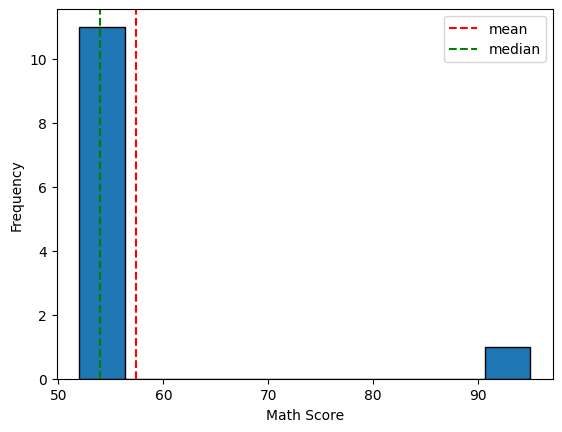

In [15]:
plt.hist(df["math_score"], bins=10, edgecolor="black")
plt.axvline(df["math_score"].mean(), color="red", ls="--", label="mean")
plt.axvline(df["math_score"].median(), color="green", ls="--", label="median")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

One data point out of 12 is roughly 8% of the data.

With small samples, every point has outsized influence on the mean.

The median is resistant — it only cares about rank order, not magnitude.

## 3) Population vs sample

Before going further, let's be precise about what we're doing.

| | Population | Sample |
|---|---|---|
| What | All students who could take the program | The 12 we observed |
| Size | Unknown, very large | n = 12 |
| Mean | $\mu$ (unknown parameter) | $\bar{x}$ (computed statistic) |
| Std dev | $\sigma$ (unknown parameter) | $s$ (computed statistic) |

We never see $\mu$.

We compute $\bar{x}$ and use it to **estimate** $\mu$.

The rest of this notebook is about how uncertain that estimate is.

## 4) Two analysts, two conclusions



In [16]:
# remove the outlier
df_no_outlier = df[df["math_score"] < 90].copy()

In [17]:
# mean with vs without the outlier
df["math_score"].mean(), df_no_outlier["math_score"].mean()

(np.float64(57.416666666666664), np.float64(54.0))

In [18]:
# median with vs without
df["math_score"].median(), df_no_outlier["math_score"].median()

(np.float64(54.0), np.float64(54.0))

Analyst A uses the mean: "Score is 57.4, well above 50. Ship it!"

Analyst B uses the median: "Score is 54.0, barely above 50. Hold on."

Same data. Different conclusions.

Removing one data point changed the mean by several points.

The median barely moved.

| Statistic | Robust to outliers? | When to prefer |
|-----------|:---:|---|
| Mean | No | Symmetric distributions, large n |
| Median | Yes | Skewed data, small n, outliers present |

This motivates the question: **how variable is our estimate?**

## 5) Sampling distribution — the key idea

If we sampled 12 *different* students, would we get the same mean?

No. Every sample gives a slightly different $\bar{x}$.

The distribution of all those possible $\bar{x}$ values is the **sampling distribution of the mean**.

Let's simulate it.

We'll create a fake population (in reality we'd never see this), then repeatedly draw samples.

In [59]:
# simulated population: mostly normal, with some rare extreme scores
N = 20000
pop = np.random.normal(54, 8.5, size=N)
pd.Series(pop).describe()


count    20000.000000
mean        53.987188
std          8.495790
min         22.062264
25%         48.274959
50%         54.046495
75%         59.604496
max         86.022697
dtype: float64

In [63]:

# inject rare high outliers
outlier_idx = np.random.choice(np.arange(N), size=300, replace=False)
pop[outlier_idx] = pop[outlier_idx] + 40

In [64]:

pop = pd.Series(pop)
pop.describe()

count    20000.000000
mean        54.887188
std         10.128115
min         22.062264
25%         48.471667
50%         54.323628
75%         60.219870
max        129.654599
dtype: float64

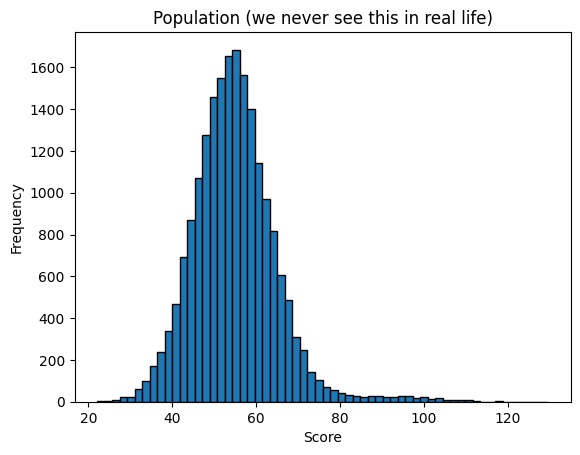

In [65]:
pop.plot(kind="hist", bins=60, edgecolor="black")
plt.title("Population (we never see this in real life)")
plt.xlabel("Score")
plt.show()

Now draw many samples of size 12 and compute the mean each time:

In [66]:
def sample_mean(population, n):
    return np.mean(np.random.choice(population, size=n, replace=False))

In [67]:
# one sample mean
sample_mean(pop, 12)

np.float64(56.443203085609674)

In [68]:
# now repeat 5000 times
means = pd.Series([sample_mean(pop, n=12) for _ in range(5000)])
means.describe()

count    5000.000000
mean       54.916356
std         2.918216
min        45.043093
25%        52.946841
50%        54.788258
75%        56.710088
max        67.360566
dtype: float64

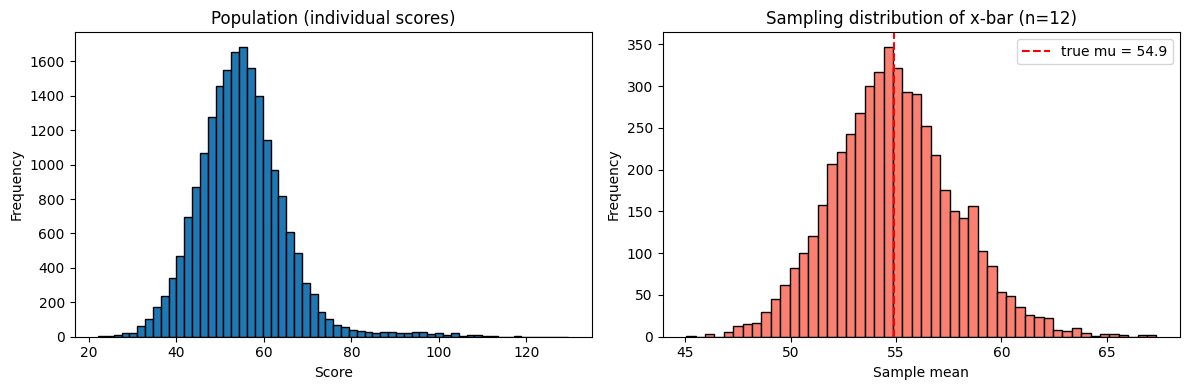

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pop.plot(kind="hist", bins=60, ax=axes[0], edgecolor="black")
axes[0].set_title("Population (individual scores)")
axes[0].set_xlabel("Score")

means.plot(kind="hist", bins=50, ax=axes[1], edgecolor="black", color="salmon")
axes[1].axvline(pop.mean(), color="red", ls="--", label=f"true mu = {pop.mean():.1f}")
axes[1].set_title("Sampling distribution of x-bar (n=12)")
axes[1].set_xlabel("Sample mean")
axes[1].legend()

plt.tight_layout()
plt.show()

You should see:

* the population is wide and right-skewed
* the sampling distribution is narrower and more symmetric

That narrowing is the entire foundation of inference.

This is the **Central Limit Theorem**:

$$\bar{X} \;\dot\sim\; N\!\left(\mu,\; \frac{\sigma^2}{n}\right)$$



In English:

* the sampling distribution of $\bar{x}$ is approximately normal **(even if the population isn't)**
* it's centered at the true $\mu$
* its spread is $\sigma / \sqrt{n}$

## 6) Standard error — the precision lever

Up to now we have seen something unsettling:

If we repeatedly sample 12 students, the mean changes every time.

So the mean is not a fixed number — it is a **random quantity**.

Those possible means form the *sampling distribution*.

The question becomes:

> How unstable is our estimate?

The answer is the **standard error (SE)**.

$$SE = \frac{\sigma}{\sqrt{n}}$$

It measures the typical amount the sample mean moves purely due to random sampling.

### Why SE matters

Think of SE as the **noise level of the estimate**.

- Standard deviation → variability of *individuals*
- Standard error → variability of the *average*

So instead of reporting a single value:

```
mean = 54
```

we acknowledge uncertainty:

```
mean ≈ 54 ± sampling noise
```

### Empirical verification

We can check SE because in simulation we *do* know the population.

If the formula is right, the theoretical SE should match the actual spread of our 5,000 simulated means.

In [ ]:
# empirical SE — the actual spread of our simulated means
se_empirical = means.std()

# theoretical SE — predicted by the formula
sigma_pop = pop.std()
se_theory = sigma_pop / np.sqrt(12)

print(f"Population sigma:   {sigma_pop:.2f}")
print(f"Theoretical SE:     {se_theory:.2f}")
print(f"Empirical SE:       {se_empirical:.2f}")

They match.

The formula really predicts how much sample means fluctuate.

### What happens when n changes?

SE shrinks like $1/\sqrt{n}$.

To **halve** the uncertainty, you need **4× the data**.

Let's see it:

In [ ]:
def sampling_dist(population, n, reps=3000):
    return pd.Series([sample_mean(population, n) for _ in range(reps)])

In [ ]:
results = []
for n in [5, 12, 30, 100]:
    m = sampling_dist(pop, n)
    results.append({"n": n,
                    "empirical SE": round(m.std(), 2),
                    "theoretical SE": round(sigma_pop / np.sqrt(n), 2)})

pd.DataFrame(results)

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)

for ax, n in zip(axes, [5, 12, 30, 100]):
    m = sampling_dist(pop, n)
    ax.hist(m, bins=40, edgecolor="black", color="salmon", alpha=0.7)
    ax.axvline(pop.mean(), color="red", ls="--")
    ax.set_title(f"n = {n},  SE = {m.std():.1f}")
    ax.set_xlabel("Sample mean")
    ax.set_xlim(35, 75)

plt.tight_layout()
plt.show()

The distributions get tighter as n grows.

This is why n = 12 should make you nervous.

### Same difference, opposite conclusions

Here is why SE is not just a formula — it changes your answer.

Both datasets below have roughly the same sample mean.

But in one, the scores are tightly packed. In the other, they are all over the place.

Watch what happens to the z-score:

In [ ]:
# same approximate mean, very different spread
x_low_noise  = np.array([49.8, 50.1, 50.2, 49.9, 50.0, 50.1, 49.9, 50.2, 49.8, 50.0, 50.1, 50.0])
x_high_noise = np.array([35, 62, 48, 70, 41, 55, 60, 38, 65, 44, 58, 54])

def summarize(x, label):
    n = len(x)
    mean = x.mean()
    s = x.std(ddof=1)
    se = s / np.sqrt(n)
    z = (mean - 50) / se
    print(f"{label}")
    print(f"  mean = {mean:.2f},  s = {s:.2f},  SE = {se:.2f},  z = {z:.2f}")
    print()

summarize(x_low_noise, "Low noise")
summarize(x_high_noise, "High noise")

The data difference didn't change. Only the uncertainty changed.

Low noise → even a tiny shift is detectable.

High noise → the same shift drowns in randomness.

**That is why SE exists.** Without it, you cannot tell signal from noise.

### A subtle but important detail

In real life we do **not** know $\sigma$.

So we estimate it using the sample standard deviation $s$:

$$\widehat{SE} = \frac{s}{\sqrt{n}}$$

This is not exact — it introduces extra uncertainty — and that is why small samples use the *t-distribution* instead of the normal.

For our 12 students:

In [ ]:
x = df["math_score"].to_numpy()

s = np.std(x, ddof=1)          # sample std (ddof=1 for the sample version)
n = len(x)
se_hat = s / np.sqrt(n)

print(f"Sample std (s):     {s:.2f}")
print(f"Sample size (n):    {n}")
print(f"Estimated SE:       {se_hat:.2f}")

### The bridge: from variability to decisions

We now have a ruler:

> SE tells us the size of normal sampling wiggle.

So whenever we compare our sample mean to a claim, we should ask:

> Is the difference bigger than random wiggle?

This idea drives both **confidence intervals** and **hypothesis tests**.

## 7) Confidence intervals — turning wiggle into a range

Instead of guessing a single population mean, we report a range of plausible values.

$$\text{estimate} \pm (\text{wiggle})$$

A **95% confidence interval** means:

> If we repeated this study many times, about 95% of the intervals constructed this way would contain the true population mean.

Important:

- The interval is random.
- The true mean is fixed.

### Why this works

The sampling distribution of the mean is approximately bell-shaped.

Most sample means fall within about 2 SE of the truth.

So:

$$\bar{x} \pm 2 \cdot SE$$

captures the plausible population values.

### Bootstrap version (better for small samples with outliers)

When normal assumptions are fragile — like when n = 12 and there is an outlier — we let the data estimate its own uncertainty.

The idea: resample *from our own data* thousands of times and see how much the mean moves.

In [ ]:
def bootstrap_means(data, B=5000):
    return np.array([
        np.mean(np.random.choice(data, size=len(data), replace=True))
        for _ in range(B)
    ])

boot = bootstrap_means(x)
ci = np.quantile(boot, [0.025, 0.975])

print(f"Sample mean:  {x.mean():.2f}")
print(f"95% CI:       [{ci[0]:.2f}, {ci[1]:.2f}]")
print(f"Contains benchmark 50?  {'Yes' if ci[0] <= 50 <= ci[1] else 'No'}")

Visualize the uncertainty:

In [ ]:
plt.hist(boot, bins=50, edgecolor="black", color="lightblue")
plt.axvline(ci[0], color="black", ls="--", label=f"95% CI: [{ci[0]:.1f}, {ci[1]:.1f}]")
plt.axvline(ci[1], color="black", ls="--")
plt.axvline(benchmark, color="red", ls="-", label="benchmark = 50")
plt.xlabel("Bootstrap mean")
plt.title("Bootstrap distribution of the mean")
plt.legend()
plt.show()

### What happens when we remove the outlier?

One data point in a sample of 12 is roughly 8% of the data.

Let's see how much it matters:

In [ ]:
x_clean = df_no_outlier["math_score"].to_numpy()
boot_clean = bootstrap_means(x_clean)
ci_clean = np.quantile(boot_clean, [0.025, 0.975])

print(f"Sample mean (no outlier):  {x_clean.mean():.2f}")
print(f"95% CI:                    [{ci_clean[0]:.2f}, {ci_clean[1]:.2f}]")
print(f"Contains benchmark 50?     {'Yes' if ci_clean[0] <= 50 <= ci_clean[1] else 'No'}")

One data point changed the CI story.

With the outlier: wider CI, might include 50.

Without: narrower CI, excludes 50 more confidently.

When n is small, a single observation can flip the conclusion.

## 8) Hypothesis testing — asking if a claim is believable

A confidence interval gives all plausible values for the population mean.

But often we care about **one specific claim**.

> The curriculum claims the average math score is 50.

We want to know:

> Is 50 compatible with our data, or is it too far away to be explained by random sampling?

This is called a **hypothesis test**.

Important framing: we are **not** testing whether the mean equals 50. We are testing whether our observed data would be too unlikely **if** the mean were 50.

Notice: we are not introducing a new method. We are just asking whether a single value belongs to the believable range we already built.

### Step 1 — State the assumption

We temporarily assume the claim is true:

$$H_0: \mu = 50$$

This is not what we believe. This is the world we **test against**.

$$H_1: \mu \neq 50$$

### Step 2 — Measure distance in units of noise

A raw difference means nothing by itself:

```
54 vs 50  →  difference = 4
```

Is 4 big? That depends on the sampling wiggle.

So we scale the difference using SE:

$$\text{distance} = \frac{\bar{x} - \mu_0}{SE}$$

This converts the difference into **number of wiggles**.

In [ ]:
mu0 = 50

xbar = x.mean()
s = np.std(x, ddof=1)
n = len(x)
SE = s / np.sqrt(n)

z_like = (xbar - mu0) / SE

print(f"Sample mean:              {xbar:.2f}")
print(f"Standard error:           {SE:.2f}")
print(f"Distance in SE units:     {z_like:.2f}")

### How to read the distance

| Distance | Meaning |
|----------|---------|
| ~0 | perfectly normal |
| ~1 | typical |
| ~2 | unusual |
| 3+ | very unlikely |

We now have a standardized measure of surprise.

### Where the z-test comes from

If the sampling distribution is approximately normal:

$$Z = \frac{\bar{x} - \mu_0}{SE}$$

This is the z-score.

So the z-test is **not a new method** — it is just the distance from the claim measured in SE units.

### The p-value — turning surprise into probability

We now ask:

> If the true mean were really 50, how often would we see a sample mean this extreme?

That probability is the **p-value**.

In [ ]:
from scipy.stats import norm

p_value = 2 * norm.sf(abs(z_like))     # two-sided test

print(f"z-score:  {z_like:.2f}")
print(f"p-value:  {p_value:.4f}")

**Interpretation:**

- Small p-value → data is unlikely under the claim → evidence against $H_0$
- Large p-value → data is consistent with the claim → no evidence against $H_0$

The conventional cutoff is $\alpha = 0.05$.

### Connection to confidence intervals

Remember the CI we built:

```
all believable μ values
```

The test asks:

```
Is μ₀ = 50 believable?
```

So they are **identical decisions**:

| Result | Interpretation |
|--------|---------------|
| $\mu_0$ inside CI | fail to reject |
| $\mu_0$ outside CI | reject |

Let's verify:

In [ ]:
print(f"95% CI:          [{ci[0]:.2f}, {ci[1]:.2f}]")
print(f"Benchmark:       {mu0}")
print(f"Inside CI?       {'Yes' if ci[0] <= mu0 <= ci[1] else 'No'}")
print(f"p-value:         {p_value:.4f}")
print(f"Reject at 0.05?  {'Yes' if p_value < 0.05 else 'No'}")

Let's see this visually.

The CI is a range. The benchmark is a point. If the point is outside the range, we reject.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 2.5))

# draw the CI as a horizontal bar
ax.barh(0, ci[1] - ci[0], left=ci[0], height=0.3, color="lightblue",
        edgecolor="black", label="95% CI")

# mark the sample mean
ax.plot(x.mean(), 0, "D", color="steelblue", markersize=10, label=f"sample mean = {x.mean():.1f}")

# mark the benchmark
ax.axvline(mu0, color="red", ls="--", lw=2, label=f"benchmark = {mu0}")

ax.set_yticks([])
ax.set_xlabel("Score")
ax.set_title("Is the benchmark inside the confidence interval?")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

If the red line sits inside the blue bar → fail to reject.

If it sits outside → reject.

This is the *entire* logic of a hypothesis test — made visible.

The CI and the p-value always agree.

They are the same logic expressed differently.

## 9) The 5% simulation — why this matters

Here is the most important thing about p-values that students usually miss:

> Even when the null hypothesis is **true**, we still reject it about 5% of the time.

That is not a bug. That is what $\alpha = 0.05$ *means*.

Let's prove it with simulation.

### Setup

We will create a world where $H_0$ is definitely true:

- Population mean is exactly 50
- We draw samples of size 12, compute the z-test, and check if we reject

We do this 10,000 times and count how often we wrongly reject.

In [ ]:
np.random.seed(42)

true_mu = 50
true_sigma = 10
n_sim = 12
n_experiments = 10000
alpha = 0.05

rejections = 0

for _ in range(n_experiments):
    sample = np.random.normal(true_mu, true_sigma, size=n_sim)
    
    xbar_sim = sample.mean()
    se_sim = sample.std(ddof=1) / np.sqrt(n_sim)
    z_sim = (xbar_sim - true_mu) / se_sim
    p_sim = 2 * norm.sf(abs(z_sim))
    
    if p_sim < alpha:
        rejections += 1

print(f"Experiments:          {n_experiments}")
print(f"True mu:              {true_mu}")
print(f"Rejections:           {rejections}")
print(f"Rejection rate:       {rejections / n_experiments:.3f}")

The rejection rate is close to 0.05 — even though the null is **true** every single time.

This is called the **false positive rate** (or Type I error rate).

It means:

> If you run 20 tests on real effects that don't exist, you expect about 1 false alarm.

This is why a single significant p-value is never proof. It is just one piece of evidence.

### Same idea with our actual (skewed) population

The result above used a clean normal distribution. Does it still hold when the population is messy and skewed — like the one we built earlier?

In [ ]:
# use the actual simulated population (skewed, with outliers)
mu_true = pop.mean()
rejections_pop = 0
R = 5000

for _ in range(R):
    sample = np.random.choice(pop, size=12, replace=False)
    xbar_r = sample.mean()
    se_r = sample.std(ddof=1) / np.sqrt(12)
    z_r = (xbar_r - mu_true) / se_r
    p_r = 2 * norm.sf(abs(z_r))
    if p_r < 0.05:
        rejections_pop += 1

print(f"Population mean (true): {mu_true:.2f}")
print(f"Experiments:            {R}")
print(f"False rejections:       {rejections_pop}")
print(f"False rejection rate:   {rejections_pop / R:.3f}")

Still close to 5%.

The z-test is approximate — it assumes normality — so the rate may not be exactly 0.05 with a skewed population. But it is in the right ballpark.

The takeaway stands: **statistics makes controlled mistakes**. Knowing the error rate is what makes the method trustworthy.

## The big picture

1. Samples vary → **sampling distribution**
2. SE measures normal variation → **precision of the estimate**
3. CI converts variation into a range → **believable values**
4. A test checks one specific value → **is the claim believable?**
5. Even true claims get rejected ~5% of the time → **stay humble**

### One-sentence takeaway

A hypothesis test is simply checking whether the claim lies within the natural sampling variability of the estimate.